<a href="https://colab.research.google.com/github/akashmestha/Bus-Book/blob/main/Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
!pip install -q torchinfo matplotlib seaborn scikit-learn kaggle opendatasets
import os, time, json, warnings, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from datetime import datetime
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import datasets, transforms, models
from torchinfo import summary
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {device}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

✅ Device: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB


In [28]:
DATASET_ID = 'DS4'
DATA_ROOT  = f'/content/datasets/{DATASET_ID}'
os.makedirs(DATA_ROOT, exist_ok=True)
print(f'Selected dataset: {DATASET_ID}')

Selected dataset: DS4


In [29]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_cf4e3b941714fef8ef804ed56ace7914'
os.environ['KAGGLE_USERNAME'] = 'akashmestha'

# Write kaggle.json using these credentials
import json
kaggle_creds = {'username': 'akashmestha', 'key': 'KGAT_cf4e3b941714fef8ef804ed56ace7914'}
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as f:
    json.dump(kaggle_creds, f)
!chmod 600 ~/.kaggle/kaggle.json
print("✅ Kaggle configured")

✅ Kaggle configured


In [30]:
# ── Download selected dataset ──────────────────────────────────\n
import subprocess
KAGGLE_DATASETS = {
    'DS4': 'rm1000/grape-disease-dataset-original',
    'DS6': 'nirmalsankalana/grape400-dataset',
    'DS7': 'zienabesam/grape-plant-from-plant-village-dataset',
    'DS8': 'asadaliprofile/grapes',
    'DS9': 'nicolaasregnier/pinotnoirgrapes',
}

ZENODO_DATASETS = {
    'DS1': 'https://zenodo.org/records/14936376/files/dataset.zip',
}

MENDELEY_NOTE = {
    'DS2': 'https://data.mendeley.com/datasets/j4xs3kh3fd/2',
    'DS3': 'https://data.mendeley.com/datasets/wkymf8bhcg/3',
    'DS5': 'https://data.mendeley.com/datasets/8nnd2ypcv3/1',
}

if DATASET_ID in KAGGLE_DATASETS:
    slug = KAGGLE_DATASETS[DATASET_ID]
    print(f'Downloading from Kaggle: {slug}')
    !kaggle datasets download -d {slug} -p {DATA_ROOT} --unzip
    print('✅ Kaggle download complete')

elif DATASET_ID == 'DS1':
    url = ZENODO_DATASETS['DS1']
    print(f'Downloading from Zenodo...')
    !wget -q {url} -O {DATA_ROOT}/dataset.zip && unzip -q {DATA_ROOT}/dataset.zip -d {DATA_ROOT}
    print('✅ Zenodo download complete')

elif DATASET_ID in MENDELEY_NOTE:
    print(f'⚠️  Mendeley datasets require manual download.')
    print(f'   1. Go to: {MENDELEY_NOTE[DATASET_ID]}')
    print(f'   2. Click Download All → save ZIP to your machine')
    print(f'   3. Run the next cell to upload it to Colab')

else:
    print('Unknown dataset ID')

Dataset URL: https://www.kaggle.com/datasets/rm1000/grape-disease-dataset-original
License(s): CC0-1.0
100% 151M/151M [00:00<00:00, 182MB/s]

✅ Kaggle download complete


In [31]:
# ── (Mendeley only) Upload zip manually and extract ────────────

# from google.colab import files
# uploaded = files.upload()
# fname = list(uploaded.keys())[0]
# !unzip -q {fname} -d {DATA_ROOT}
print('Manual upload cell — uncomment if needed for Mendeley datasets')

Manual upload cell — uncomment if needed for Mendeley datasets


In [32]:
# Find the folder that contains class subdirectories
def find_image_root(base_path):
    """Walk dirs until we find one with image-containing subdirs."""
    base = Path(base_path)
    IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    for root, dirs, files in os.walk(base):
        images = [f for f in files if Path(f).suffix.lower() in IMG_EXTS]
        if images and any(True for d in dirs if (Path(root)/d).is_dir()):
            return root
        elif dirs and all(
            any(Path(f).suffix.lower() in IMG_EXTS
                for f in os.listdir(Path(root)/d))
            for d in dirs if (Path(root)/d).is_dir()
        ):
            return root
    # fallback: deepest dir with class subdirs
    for root, dirs, files in os.walk(base):
        if dirs and not any(d.startswith('.') for d in dirs):
            return root
    return base_path

IMAGE_ROOT = find_image_root(DATA_ROOT)
print(f'Image root detected: {IMAGE_ROOT}')

# Show directory tree
class_dirs = [d for d in sorted(os.listdir(IMAGE_ROOT))
              if os.path.isdir(os.path.join(IMAGE_ROOT, d))]
print(f' 📂 Classes ({len(class_dirs)} found):')
class_counts = {}
total = 0
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
for cls in class_dirs:
    imgs = [f for f in os.listdir(os.path.join(IMAGE_ROOT, cls))
            if Path(f).suffix.lower() in IMG_EXTS]
    class_counts[cls] = len(imgs)
    total += len(imgs)
    print(f'   {cls:40s} → {len(imgs):5d} images')

print(f' 📊 DATASET PARAMETERS [{DATASET_ID}]')
print(f'   Total images   : {total}')
print(f'   Number of classes: {len(class_dirs)}')
print(f'   Classes        : {class_dirs}')

# Store for later
DATASET_PARAMS = {
    'id': DATASET_ID,
    'total_images': total,
    'num_classes': len(class_dirs),
    'classes': class_dirs,
    'class_counts': class_counts
}

Image root detected: /content/datasets/DS4/Original Data/test
 📂 Classes (4 found):
   Black Rot                                →   472 images
   ESCA                                     →   480 images
   Healthy                                  →   423 images
   Leaf Blight                              →   430 images
 📊 DATASET PARAMETERS [DS4]
   Total images   : 1805
   Number of classes: 4
   Classes        : ['Black Rot', 'ESCA', 'Healthy', 'Leaf Blight']


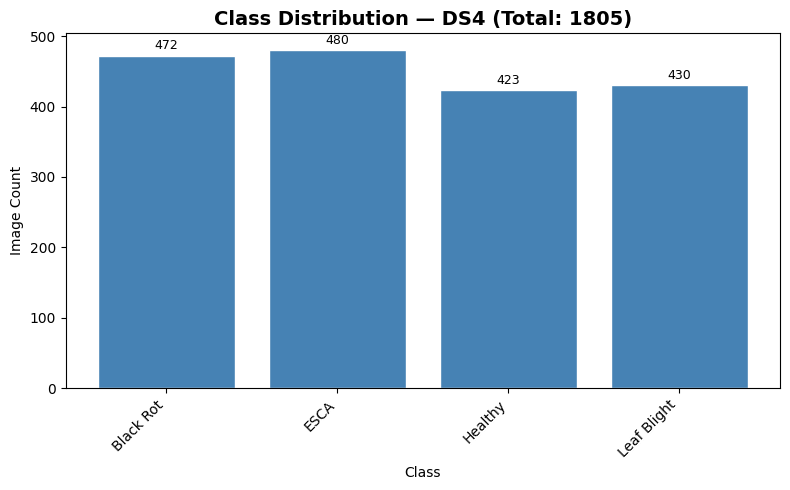

Chart saved ✅


In [33]:
# Plot class distribution
fig, ax = plt.subplots(figsize=(max(8, len(class_dirs)*1.2), 5))
bars = ax.bar(class_counts.keys(), class_counts.values(), color='steelblue', edgecolor='white')
ax.set_title(f'Class Distribution — {DATASET_ID} (Total: {total})', fontsize=14, fontweight='bold')
ax.set_xlabel('Class')
ax.set_ylabel('Image Count')
plt.xticks(rotation=45, ha='right')
for bar, count in zip(bars, class_counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(count),
            ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(f'/content/class_dist_{DATASET_ID}.png', dpi=150)
plt.show()
print('Chart saved ✅')

In [34]:
# ══════════════════════════════════════════════════════════════
#  MASTER CONFIGURATION — edit these values
# ══════════════════════════════════════════════════════════════

CFG = {
    # ── Dataset split (choose one) ─────────────────────────────
    'split': '70_20_10',          # '70_20_10'  or  '80_10_10'

    # ── Training ───────────────────────────────────────────────
    'learning_rate'  : 0.001,      # 0.1 | 0.01 | 0.001
    'batch_size'     : 32,         # 8 | 16 | 32 | 64
    'num_epochs'     : 50,         # 50 | 100 | 150 | 200
    'optimizer_name' : 'Adam',     # 'Adam' | 'SGD' | 'RMSProp'
    'dropout_rate'   : 0.4,        # 0.0 – 0.6

    # ── Model ──────────────────────────────────────────────────
    'model_name'     : 'resnet18', # 'resnet18' | 'efficientnet_b0' | 'inception_v3'
    'img_size'       : 224,        # 224 for ResNet/EfficientNet; use 299 for InceptionV3
    'pretrained'     : True,
    'fine_tune_all'  : True,       # True = fine-tune all layers; False = head only

    # ── Misc ───────────────────────────────────────────────────
    'seed'           : 42,
    'num_workers'    : 2,
    'early_stopping_patience': 10, # 0 = disabled
}

# ── Auto-adjust image size for InceptionV3 ─────────────────────
if CFG['model_name'] == 'inception_v3':
    CFG['img_size'] = 299
    print('📐 InceptionV3 detected → image size auto-set to 299×299')

# ── Set seeds ──────────────────────────────────────────────────
torch.manual_seed(CFG['seed'])
np.random.seed(CFG['seed'])

print('Configuration:')
for k, v in CFG.items():
    print(f'  {k:30s}: {v}')

Configuration:
  split                         : 70_20_10
  learning_rate                 : 0.001
  batch_size                    : 32
  num_epochs                    : 50
  optimizer_name                : Adam
  dropout_rate                  : 0.4
  model_name                    : resnet18
  img_size                      : 224
  pretrained                    : True
  fine_tune_all                 : True
  seed                          : 42
  num_workers                   : 2
  early_stopping_patience       : 10


In [35]:
IMG_SIZE = CFG['img_size']

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# Load full dataset (train transforms; we'll apply val transforms manually)
full_dataset = datasets.ImageFolder(IMAGE_ROOT, transform=train_transforms)
NUM_CLASSES  = len(full_dataset.classes)
CLASS_NAMES  = full_dataset.classes
N_TOTAL      = len(full_dataset)

# Split
if CFG['split'] == '70_20_10':
    n_train = int(0.70 * N_TOTAL)
    n_val   = int(0.20 * N_TOTAL)
    n_test  = N_TOTAL - n_train - n_val
else:  # 80_10_10
    n_train = int(0.80 * N_TOTAL)
    n_val   = int(0.10 * N_TOTAL)
    n_test  = N_TOTAL - n_train - n_val

train_ds, val_ds, test_ds = random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(CFG['seed'])
)

# Apply val/test transforms
val_ds.dataset  = datasets.ImageFolder(IMAGE_ROOT, transform=val_test_transforms)
test_ds.dataset = datasets.ImageFolder(IMAGE_ROOT, transform=val_test_transforms)

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,
                          num_workers=CFG['num_workers'], pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG['batch_size'], shuffle=False,
                          num_workers=CFG['num_workers'], pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG['batch_size'], shuffle=False,
                          num_workers=CFG['num_workers'], pin_memory=True)

print(f'✅ Data loaders ready')
print(f'   Split: {CFG["split"]} → Train: {n_train} | Val: {n_val} | Test: {n_test}')
print(f'   Classes ({NUM_CLASSES}): {CLASS_NAMES}')
print(f'   Batches — Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

✅ Data loaders ready
   Split: 70_20_10 → Train: 1263 | Val: 361 | Test: 181
   Classes (4): ['Black Rot', 'ESCA', 'Healthy', 'Leaf Blight']
   Batches — Train: 40 | Val: 12 | Test: 6


In [36]:
def build_model(model_name, num_classes, dropout_rate, pretrained=True, fine_tune_all=True):
    """Build ResNet-18, EfficientNet-B0, or InceptionV3 with custom head."""
    weights = 'DEFAULT' if pretrained else None

    # ── ResNet-18 ─────────────────────────────────────────────
    if model_name == 'resnet18':
        model = models.resnet18(weights=weights)
        if not fine_tune_all:
            for param in model.parameters():
                param.requires_grad = False
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate / 2),
            nn.Linear(256, num_classes)
            # Note: Softmax is applied inside CrossEntropyLoss (logits)
        )

    # ── EfficientNet-B0 ───────────────────────────────────────
    elif model_name == 'efficientnet_b0':
        model = models.efficientnet_b0(weights=weights)
        if not fine_tune_all:
            for param in model.parameters():
                param.requires_grad = False
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(in_features, num_classes)
        )

    # ── InceptionV3 ───────────────────────────────────────────
    elif model_name == 'inception_v3':
        model = models.inception_v3(weights=weights, aux_logits=True)
        if not fine_tune_all:
            for param in model.parameters():
                param.requires_grad = False
        # Primary classifier
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate / 2),
            nn.Linear(256, num_classes)
        )
        # Auxiliary classifier (used during training)
        model.AuxLogits.fc = nn.Linear(model.AuxLogits.fc.in_features, num_classes)

    else:
        raise ValueError(f'Unknown model: {model_name}')

    return model.to(device)


def build_optimizer(model, optimizer_name, lr):
    if optimizer_name == 'Adam':
        return optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    elif optimizer_name == 'SGD':
        return optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=1e-4)
    elif optimizer_name == 'RMSProp':
        return optim.RMSprop(model.parameters(), lr=lr, weight_decay=1e-4)
    else:
        raise ValueError(f'Unknown optimizer: {optimizer_name}')


# Build and preview
model = build_model(CFG['model_name'], NUM_CLASSES, CFG['dropout_rate'],
                    CFG['pretrained'], CFG['fine_tune_all'])

print(f'✅ Model: {CFG["model_name"]} built')
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'   Total params    : {total_params:,}')
print(f'   Trainable params: {trainable:,}')

✅ Model: resnet18 built
   Total params    : 11,308,868
   Trainable params: 11,308,868


In [37]:
def measure_memory_mb():
    if torch.cuda.is_available():
        return torch.cuda.memory_allocated() / 1e6
    return 0.0


def train_one_epoch(model, loader, criterion, optimizer, model_name):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        # InceptionV3 returns (main_output, aux_output) during training
        if model_name == 'inception_v3' and isinstance(outputs, tuple):
            main_loss = criterion(outputs[0], labels)
            aux_loss  = criterion(outputs[1], labels)
            loss      = main_loss + 0.4 * aux_loss
            logits    = outputs[0]
        else:
            loss   = criterion(outputs, labels)
            logits = outputs
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * inputs.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += inputs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, model_name):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        if isinstance(outputs, tuple): outputs = outputs[0]
        loss   = criterion(outputs, labels)
        probs  = torch.softmax(outputs, dim=1)
        preds  = outputs.argmax(dim=1)
        total_loss += loss.item() * inputs.size(0)
        correct    += (preds == labels).sum().item()
        total      += inputs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    return (total_loss / total, correct / total,
            np.array(all_preds), np.array(all_labels), np.array(all_probs))


def compute_auc(all_labels, all_probs, num_classes):
    try:
        if num_classes == 2:
            return roc_auc_score(all_labels, all_probs[:, 1])
        else:
            lb = label_binarize(all_labels, classes=list(range(num_classes)))
            return roc_auc_score(lb, all_probs, multi_class='ovr', average='macro')
    except Exception:
        return 0.0


def train_model(model, train_loader, val_loader, cfg, num_classes):
    criterion = nn.CrossEntropyLoss()
    optimizer = build_optimizer(model, cfg['optimizer_name'], cfg['learning_rate'])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    patience_counter = 0
    best_weights = None
    total_train_time = 0.0
    mem_peak = 0.0

    print(f' 🚀 Training {cfg["model_name"]} | LR={cfg["learning_rate"]} | BS={cfg["batch_size"]} | Epochs={cfg["num_epochs"]}')
    print(f'   Optimizer: {cfg["optimizer_name"]} | Dropout: {cfg["dropout_rate"]} | Split: {cfg["split"]}')
    print('─' * 80)

    for epoch in range(1, cfg['num_epochs'] + 1):
        t0 = time.time()
        if torch.cuda.is_available(): torch.cuda.reset_peak_memory_stats()

        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, cfg['model_name'])
        vl_loss, vl_acc, vl_preds, vl_labels, vl_probs = evaluate(model, val_loader, criterion, cfg['model_name'])
        scheduler.step(vl_loss)

        epoch_time = time.time() - t0
        total_train_time += epoch_time
        if torch.cuda.is_available():
            mem_peak = max(mem_peak, torch.cuda.max_memory_allocated() / 1e6)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        if epoch % 5 == 0 or epoch == 1:
            print(f'  Epoch {epoch:4d}/{cfg["num_epochs"]} | '
                  f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | '
                  f'Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f} | '
                  f'Time: {epoch_time:.1f}s')

        # Save best weights
        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            best_weights  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        # Early stopping
        if cfg['early_stopping_patience'] > 0 and patience_counter >= cfg['early_stopping_patience']:
            print(f'  ⏹  Early stopping at epoch {epoch} (patience={cfg["early_stopping_patience"]})')
            break

    # Restore best weights
    if best_weights: model.load_state_dict(best_weights)
    return history, total_train_time, mem_peak


# ── RUN TRAINING ──────────────────────────────────────────────
model = build_model(CFG['model_name'], NUM_CLASSES, CFG['dropout_rate'],
                    CFG['pretrained'], CFG['fine_tune_all'])

history, total_train_time, mem_peak = train_model(
    model, train_loader, val_loader, CFG, NUM_CLASSES
)
print(f' ✅ Training complete in {total_train_time/60:.2f} min | Peak GPU mem: {mem_peak:.1f} MB')

 🚀 Training resnet18 | LR=0.001 | BS=32 | Epochs=50
   Optimizer: Adam | Dropout: 0.4 | Split: 70_20_10
────────────────────────────────────────────────────────────────────────────────
  Epoch    1/50 | Train Loss: 0.3882 Acc: 0.8892 | Val Loss: 0.4675 Acc: 0.8781 | Time: 20.1s
  Epoch    5/50 | Train Loss: 0.0915 Acc: 0.9794 | Val Loss: 0.2556 Acc: 0.9030 | Time: 9.4s
  Epoch   10/50 | Train Loss: 0.0949 Acc: 0.9731 | Val Loss: 0.0399 Acc: 0.9861 | Time: 10.4s
  Epoch   15/50 | Train Loss: 0.0186 Acc: 0.9913 | Val Loss: 0.0233 Acc: 0.9945 | Time: 11.0s
  Epoch   20/50 | Train Loss: 0.0127 Acc: 0.9968 | Val Loss: 0.0022 Acc: 1.0000 | Time: 10.0s
  Epoch   25/50 | Train Loss: 0.0050 Acc: 0.9976 | Val Loss: 0.0035 Acc: 1.0000 | Time: 10.2s
  Epoch   30/50 | Train Loss: 0.0304 Acc: 0.9945 | Val Loss: 0.0043 Acc: 1.0000 | Time: 11.4s
  ⏹  Early stopping at epoch 34 (patience=10)
 ✅ Training complete in 6.20 min | Peak GPU mem: 944.5 MB


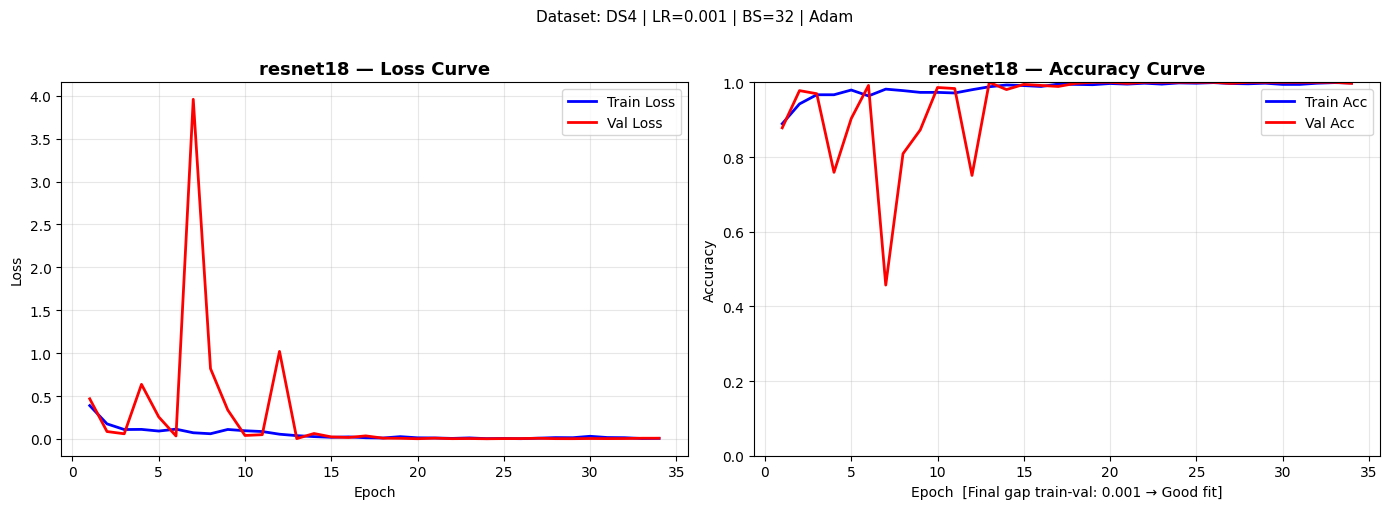

📉 Overfitting status: Good fit (train-val gap = 0.0012)


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_ran = range(1, len(history['train_loss']) + 1)

# Loss
axes[0].plot(epochs_ran, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
axes[0].plot(epochs_ran, history['val_loss'],   'r-', label='Val Loss',   linewidth=2)
axes[0].set_title(f'{CFG["model_name"]} — Loss Curve', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs_ran, history['train_acc'], 'b-', label='Train Acc', linewidth=2)
axes[1].plot(epochs_ran, history['val_acc'],   'r-', label='Val Acc',   linewidth=2)
axes[1].set_title(f'{CFG["model_name"]} — Accuracy Curve', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(alpha=0.3)

# Overfitting gap
gap = np.array(history['train_acc']) - np.array(history['val_acc'])
final_gap = gap[-1]
status = 'Overfitting' if final_gap > 0.1 else ('Underfitting' if history['val_acc'][-1] < 0.6 else 'Good fit')
axes[1].set_xlabel(f'Epoch  [Final gap train-val: {final_gap:.3f} → {status}]')

plt.suptitle(f'Dataset: {DATASET_ID} | LR={CFG["learning_rate"]} | BS={CFG["batch_size"]} | {CFG["optimizer_name"]}',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(f'/content/training_curves_{CFG["model_name"]}_{DATASET_ID}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'📉 Overfitting status: {status} (train-val gap = {final_gap:.4f})')

In [39]:
criterion = nn.CrossEntropyLoss()

# Inference time measurement
t_inf_start = time.time()
test_loss, test_acc, test_preds, test_labels, test_probs = evaluate(
    model, test_loader, criterion, CFG['model_name']
)
inference_time = time.time() - t_inf_start
per_image_ms   = (inference_time / len(test_ds)) * 1000

# Sklearn metrics
precision = precision_score(test_labels, test_preds, average='weighted', zero_division=0)
recall    = recall_score(test_labels,    test_preds, average='weighted', zero_division=0)
f1        = f1_score(test_labels,        test_preds, average='weighted', zero_division=0)
auc       = compute_auc(test_labels,     test_probs, NUM_CLASSES)

# Overfitting analysis
final_train_acc = history['train_acc'][-1]
final_val_acc   = history['val_acc'][-1]
acc_gap         = final_train_acc - final_val_acc
if acc_gap > 0.15: generalization = 'Overfitting (high)'
elif acc_gap > 0.07: generalization = 'Slight overfitting'
elif test_acc < 0.60: generalization = 'Underfitting'
else: generalization = 'Good generalization'

# GPU utilization (approximate via memory)
if torch.cuda.is_available():
    total_mem = torch.cuda.get_device_properties(0).total_memory / 1e6
    gpu_util  = f'{mem_peak:.1f} MB used / {total_mem:.0f} MB total ({100*mem_peak/total_mem:.1f}%)'
else:
    gpu_util = 'CPU only'

print('═' * 65)
print(f'  MODEL        : {CFG["model_name"].upper()}')
print(f'  DATASET      : {DATASET_ID}')
print(f'  SPLIT        : {CFG["split"]}')
print('─' * 65)
print(f'  Test Accuracy  : {test_acc:.4f}  ({test_acc*100:.2f}%)')
print(f'  Precision      : {precision:.4f}')
print(f'  Recall         : {recall:.4f}')
print(f'  F1-Score       : {f1:.4f}')
print(f'  AUC (macro)    : {auc:.4f}')
print(f'  Test Loss      : {test_loss:.4f}')
print('─' * 65)
print(f'  Training Time  : {total_train_time/60:.2f} min ({total_train_time:.0f} sec)')
print(f'  Inference Time : {inference_time:.3f} sec total | {per_image_ms:.2f} ms/image')
print(f'  Memory Usage   : {gpu_util}')
print('─' * 65)
print(f'  LR={CFG["learning_rate"]} | BS={CFG["batch_size"]} | Epochs ran: {len(history["train_acc"])} | Opt={CFG["optimizer_name"]}')
print(f'  Generalization : {generalization}')
print('═' * 65)

# Save results dict
RESULTS = {
    'model': CFG['model_name'], 'dataset': DATASET_ID,
    'split': CFG['split'], 'lr': CFG['learning_rate'],
    'batch_size': CFG['batch_size'], 'epochs_ran': len(history['train_acc']),
    'optimizer': CFG['optimizer_name'], 'dropout': CFG['dropout_rate'],
    'test_accuracy': round(test_acc, 4), 'test_loss': round(test_loss, 4),
    'precision': round(precision, 4), 'recall': round(recall, 4),
    'f1_score': round(f1, 4), 'auc': round(auc, 4),
    'train_time_min': round(total_train_time/60, 2),
    'inference_time_total_sec': round(inference_time, 3),
    'inference_ms_per_image': round(per_image_ms, 2),
    'peak_memory_mb': round(mem_peak, 1),
    'generalization': generalization,
    'final_train_acc': round(final_train_acc, 4),
    'final_val_acc': round(final_val_acc, 4),
    'acc_gap': round(acc_gap, 4),
}

═════════════════════════════════════════════════════════════════
  MODEL        : RESNET18
  DATASET      : DS4
  SPLIT        : 70_20_10
─────────────────────────────────────────────────────────────────
  Test Accuracy  : 0.9834  (98.34%)
  Precision      : 0.9836
  Recall         : 0.9834
  F1-Score       : 0.9835
  AUC (macro)    : 0.9998
  Test Loss      : 0.0318
─────────────────────────────────────────────────────────────────
  Training Time  : 6.20 min (372 sec)
  Inference Time : 0.611 sec total | 3.37 ms/image
  Memory Usage   : 944.5 MB used / 15637 MB total (6.0%)
─────────────────────────────────────────────────────────────────
  LR=0.001 | BS=32 | Epochs ran: 34 | Opt=Adam
  Generalization : Good generalization
═════════════════════════════════════════════════════════════════


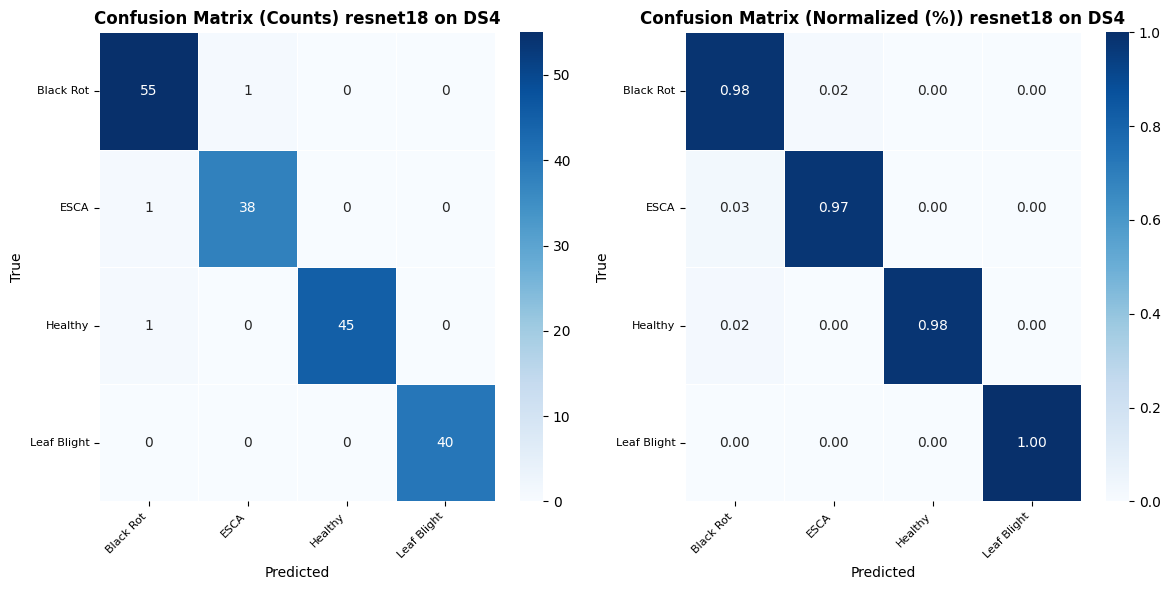

 Per-class Classification Report:
              precision    recall  f1-score   support

   Black Rot       0.96      0.98      0.97        56
        ESCA       0.97      0.97      0.97        39
     Healthy       1.00      0.98      0.99        46
 Leaf Blight       1.00      1.00      1.00        40

    accuracy                           0.98       181
   macro avg       0.98      0.98      0.98       181
weighted avg       0.98      0.98      0.98       181



In [40]:
cm = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(max(12, NUM_CLASSES*2), max(5, NUM_CLASSES*1.5)))

for ax, data, title, fmt in zip(axes,
    [cm, cm_norm], ['Counts', 'Normalized (%)'], ['d', '.2f']):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, linewidths=0.5)
    ax.set_title(f'Confusion Matrix ({title}) {CFG["model_name"]} on {DATASET_ID}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    plt.setp(ax.get_yticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
plt.savefig(f'/content/confusion_matrix_{CFG["model_name"]}_{DATASET_ID}.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-class report
print(' Per-class Classification Report:')
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES, zero_division=0))

In [41]:
# ── Helper: quick train for sweep ────────────────────────────
def quick_train(model_name, num_classes, dropout, lr, bs, epochs, opt_name, split='70_20_10'):
    # Train a model with given hyperparams and return metrics dict.
    # Re-split data with given batch size
    full = datasets.ImageFolder(IMAGE_ROOT, transform=train_transforms)
    n = len(full)
    if split == '70_20_10':
        nt, nv, nte = int(0.7*n), int(0.2*n), n-int(0.7*n)-int(0.2*n)
    else:
        nt, nv, nte = int(0.8*n), int(0.1*n), n-int(0.8*n)-int(0.1*n)
    tr, vl, te = random_split(full, [nt, nv, nte], generator=torch.Generator().manual_seed(42))
    te.dataset = datasets.ImageFolder(IMAGE_ROOT, transform=val_test_transforms)
    tr_l = DataLoader(tr, batch_size=bs, shuffle=True,  num_workers=2, pin_memory=True)
    vl_l = DataLoader(vl, batch_size=bs, shuffle=False, num_workers=2, pin_memory=True)
    te_l = DataLoader(te, batch_size=bs, shuffle=False, num_workers=2, pin_memory=True)
    cfg = {**CFG, 'learning_rate': lr, 'batch_size': bs, 'num_epochs': epochs,
           'optimizer_name': opt_name, 'dropout_rate': dropout,
           'model_name': model_name, 'early_stopping_patience': 0}
    m = build_model(model_name, num_classes, dropout, True, True)
    hist, t_time, mem = train_model(m, tr_l, vl_l, cfg, num_classes)
    crit = nn.CrossEntropyLoss()
    t0 = time.time()
    tl, ta, tp, tlb, tpr = evaluate(m, te_l, crit, model_name)
    inf_t = time.time() - t0
    f1 = f1_score(tlb, tp, average='weighted', zero_division=0)
    auc = compute_auc(tlb, tpr, num_classes)
    del m; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return {'lr': lr, 'bs': bs, 'epochs': epochs, 'opt': opt_name,
            'val_acc': hist['val_acc'][-1], 'test_acc': ta, 'test_loss': tl,
            'f1': f1, 'auc': auc, 'train_time_min': t_time/60,
            'inf_ms': (inf_t/nte)*1000, 'mem_mb': mem}

print('✅ Sweep helper defined. Run the sweep cells below.')

✅ Sweep helper defined. Run the sweep cells below.


In [42]:
# ── LEARNING RATE SWEEP ───────────────────────────────────────
# (uses fixed BS=32, Epochs=20 for speed; increase for full sweep)
LR_VALUES = [0.1, 0.01, 0.001]
lr_results = []
for lr in LR_VALUES:
    print(f' ▶ LR = {lr}')
    res = quick_train(CFG['model_name'], NUM_CLASSES, CFG['dropout_rate'],
                      lr=lr, bs=32, epochs=20, opt_name='Adam')
    lr_results.append(res)
    print(f'   val_acc={res["val_acc"]:.4f} | test_acc={res["test_acc"]:.4f} | loss={res["test_loss"]:.4f}')

df_lr = pd.DataFrame(lr_results)
print(' LR Sweep Summary:')
print(df_lr[['lr', 'val_acc', 'test_acc', 'test_loss', 'f1', 'auc']].to_string(index=False))

 ▶ LR = 0.1
 🚀 Training resnet18 | LR=0.1 | BS=32 | Epochs=20
   Optimizer: Adam | Dropout: 0.4 | Split: 70_20_10
────────────────────────────────────────────────────────────────────────────────
  Epoch    1/20 | Train Loss: 13.5518 Acc: 0.2296 | Val Loss: 30.3356 Acc: 0.3047 | Time: 11.8s
  Epoch    5/20 | Train Loss: 1.3472 Acc: 0.3666 | Val Loss: 1.0648 Acc: 0.5346 | Time: 12.2s
  Epoch   10/20 | Train Loss: 1.2164 Acc: 0.4386 | Val Loss: 1.1818 Acc: 0.4848 | Time: 12.0s
  Epoch   15/20 | Train Loss: 1.1683 Acc: 0.4576 | Val Loss: 1.0427 Acc: 0.4598 | Time: 11.8s
  Epoch   20/20 | Train Loss: 1.2575 Acc: 0.4260 | Val Loss: 1.3593 Acc: 0.3324 | Time: 11.7s
   val_acc=0.3324 | test_acc=0.4641 | loss=1.0270
 ▶ LR = 0.01
 🚀 Training resnet18 | LR=0.01 | BS=32 | Epochs=20
   Optimizer: Adam | Dropout: 0.4 | Split: 70_20_10
────────────────────────────────────────────────────────────────────────────────
  Epoch    1/20 | Train Loss: 1.6895 Acc: 0.4014 | Val Loss: 1.2052 Acc: 0.5706 | Time

In [43]:
# ── BATCH SIZE SWEEP ──────────────────────────────────────────
BS_VALUES = [8, 16, 32, 64]
bs_results = []
for bs in BS_VALUES:
    print(f' ▶ Batch size = {bs}')
    res = quick_train(CFG['model_name'], NUM_CLASSES, CFG['dropout_rate'],
                      lr=0.001, bs=bs, epochs=20, opt_name='Adam')
    bs_results.append(res)
    print(f'   val_acc={res["val_acc"]:.4f} | test_acc={res["test_acc"]:.4f}')

df_bs = pd.DataFrame(bs_results)
print(' Batch Size Sweep Summary:')
print(df_bs[['bs', 'val_acc', 'test_acc', 'test_loss', 'f1']].to_string(index=False))

 ▶ Batch size = 8
 🚀 Training resnet18 | LR=0.001 | BS=8 | Epochs=20
   Optimizer: Adam | Dropout: 0.4 | Split: 70_20_10
────────────────────────────────────────────────────────────────────────────────
  Epoch    1/20 | Train Loss: 0.6811 Acc: 0.7815 | Val Loss: 0.3112 Acc: 0.9391 | Time: 12.9s
  Epoch    5/20 | Train Loss: 0.2787 Acc: 0.9153 | Val Loss: 0.4889 Acc: 0.8338 | Time: 12.3s
  Epoch   10/20 | Train Loss: 0.2218 Acc: 0.9351 | Val Loss: 0.1127 Acc: 0.9584 | Time: 12.5s
  Epoch   15/20 | Train Loss: 0.1273 Acc: 0.9636 | Val Loss: 0.0417 Acc: 0.9889 | Time: 12.8s
  Epoch   20/20 | Train Loss: 0.1549 Acc: 0.9509 | Val Loss: 0.1004 Acc: 0.9695 | Time: 12.7s
   val_acc=0.9695 | test_acc=0.9834
 ▶ Batch size = 16
 🚀 Training resnet18 | LR=0.001 | BS=16 | Epochs=20
   Optimizer: Adam | Dropout: 0.4 | Split: 70_20_10
────────────────────────────────────────────────────────────────────────────────
  Epoch    1/20 | Train Loss: 0.5074 Acc: 0.8187 | Val Loss: 0.5975 Acc: 0.7729 | Time: 

In [44]:
# ── OPTIMIZER SWEEP ───────────────────────────────────────────
OPT_VALUES = ['Adam', 'SGD', 'RMSProp']
opt_results = []
for opt in OPT_VALUES:
    print(f' ▶ Optimizer = {opt}')
    res = quick_train(CFG['model_name'], NUM_CLASSES, CFG['dropout_rate'],
                      lr=0.001, bs=32, epochs=20, opt_name=opt)
    opt_results.append(res)
    print(f'   val_acc={res["val_acc"]:.4f} | test_acc={res["test_acc"]:.4f}')

df_opt = pd.DataFrame(opt_results)
print(' Optimizer Sweep Summary:')
print(df_opt[['opt', 'val_acc', 'test_acc', 'test_loss', 'f1', 'auc']].to_string(index=False))

 ▶ Optimizer = Adam
 🚀 Training resnet18 | LR=0.001 | BS=32 | Epochs=20
   Optimizer: Adam | Dropout: 0.4 | Split: 70_20_10
────────────────────────────────────────────────────────────────────────────────
  Epoch    1/20 | Train Loss: 0.3196 Acc: 0.9018 | Val Loss: 0.1481 Acc: 0.9501 | Time: 12.1s
  Epoch    5/20 | Train Loss: 0.0844 Acc: 0.9739 | Val Loss: 0.1006 Acc: 0.9640 | Time: 11.9s
  Epoch   10/20 | Train Loss: 0.0708 Acc: 0.9810 | Val Loss: 0.0196 Acc: 0.9972 | Time: 11.7s
  Epoch   15/20 | Train Loss: 0.1268 Acc: 0.9683 | Val Loss: 0.1826 Acc: 0.9474 | Time: 11.9s
  Epoch   20/20 | Train Loss: 0.0092 Acc: 0.9976 | Val Loss: 0.0737 Acc: 0.9834 | Time: 11.8s
   val_acc=0.9834 | test_acc=0.9890
 ▶ Optimizer = SGD
 🚀 Training resnet18 | LR=0.001 | BS=32 | Epochs=20
   Optimizer: SGD | Dropout: 0.4 | Split: 70_20_10
────────────────────────────────────────────────────────────────────────────────
  Epoch    1/20 | Train Loss: 1.2348 Acc: 0.4759 | Val Loss: 0.8790 Acc: 0.8892 | Time

In [45]:
# ── EPOCHS SWEEP ──────────────────────────────────────────────
# NOTE: This trains 4 separate models. Use a fast config.
EPOCH_VALUES = [50, 100, 150, 200]
epoch_results = []
for ep in EPOCH_VALUES:
    print(f' ▶ Epochs = {ep}')
    res = quick_train(CFG['model_name'], NUM_CLASSES, CFG['dropout_rate'],
                      lr=0.001, bs=32, epochs=ep, opt_name='Adam')
    epoch_results.append(res)
    print(f'   val_acc={res["val_acc"]:.4f} | test_acc={res["test_acc"]:.4f} | train_time={res["train_time_min"]:.1f}min')

df_ep = pd.DataFrame(epoch_results)
print(' Epochs Sweep Summary:')
print(df_ep[['epochs', 'val_acc', 'test_acc', 'test_loss', 'f1', 'train_time_min']].to_string(index=False))

 ▶ Epochs = 50
 🚀 Training resnet18 | LR=0.001 | BS=32 | Epochs=50
   Optimizer: Adam | Dropout: 0.4 | Split: 70_20_10
────────────────────────────────────────────────────────────────────────────────
  Epoch    1/50 | Train Loss: 0.3141 Acc: 0.8804 | Val Loss: 1.0536 Acc: 0.8560 | Time: 11.8s
  Epoch    5/50 | Train Loss: 0.0845 Acc: 0.9739 | Val Loss: 0.1171 Acc: 0.9557 | Time: 11.9s
  Epoch   10/50 | Train Loss: 0.1367 Acc: 0.9612 | Val Loss: 0.0915 Acc: 0.9668 | Time: 11.8s
  Epoch   15/50 | Train Loss: 0.0751 Acc: 0.9818 | Val Loss: 0.1147 Acc: 0.9640 | Time: 11.7s
  Epoch   20/50 | Train Loss: 0.0401 Acc: 0.9881 | Val Loss: 0.0106 Acc: 0.9972 | Time: 11.6s
  Epoch   25/50 | Train Loss: 0.0084 Acc: 0.9968 | Val Loss: 0.0080 Acc: 0.9972 | Time: 11.8s
  Epoch   30/50 | Train Loss: 0.0177 Acc: 0.9929 | Val Loss: 0.0066 Acc: 0.9972 | Time: 11.7s
  Epoch   35/50 | Train Loss: 0.0207 Acc: 0.9913 | Val Loss: 0.0136 Acc: 0.9945 | Time: 11.7s
  Epoch   40/50 | Train Loss: 0.0022 Acc: 0.9992

KeyboardInterrupt: 

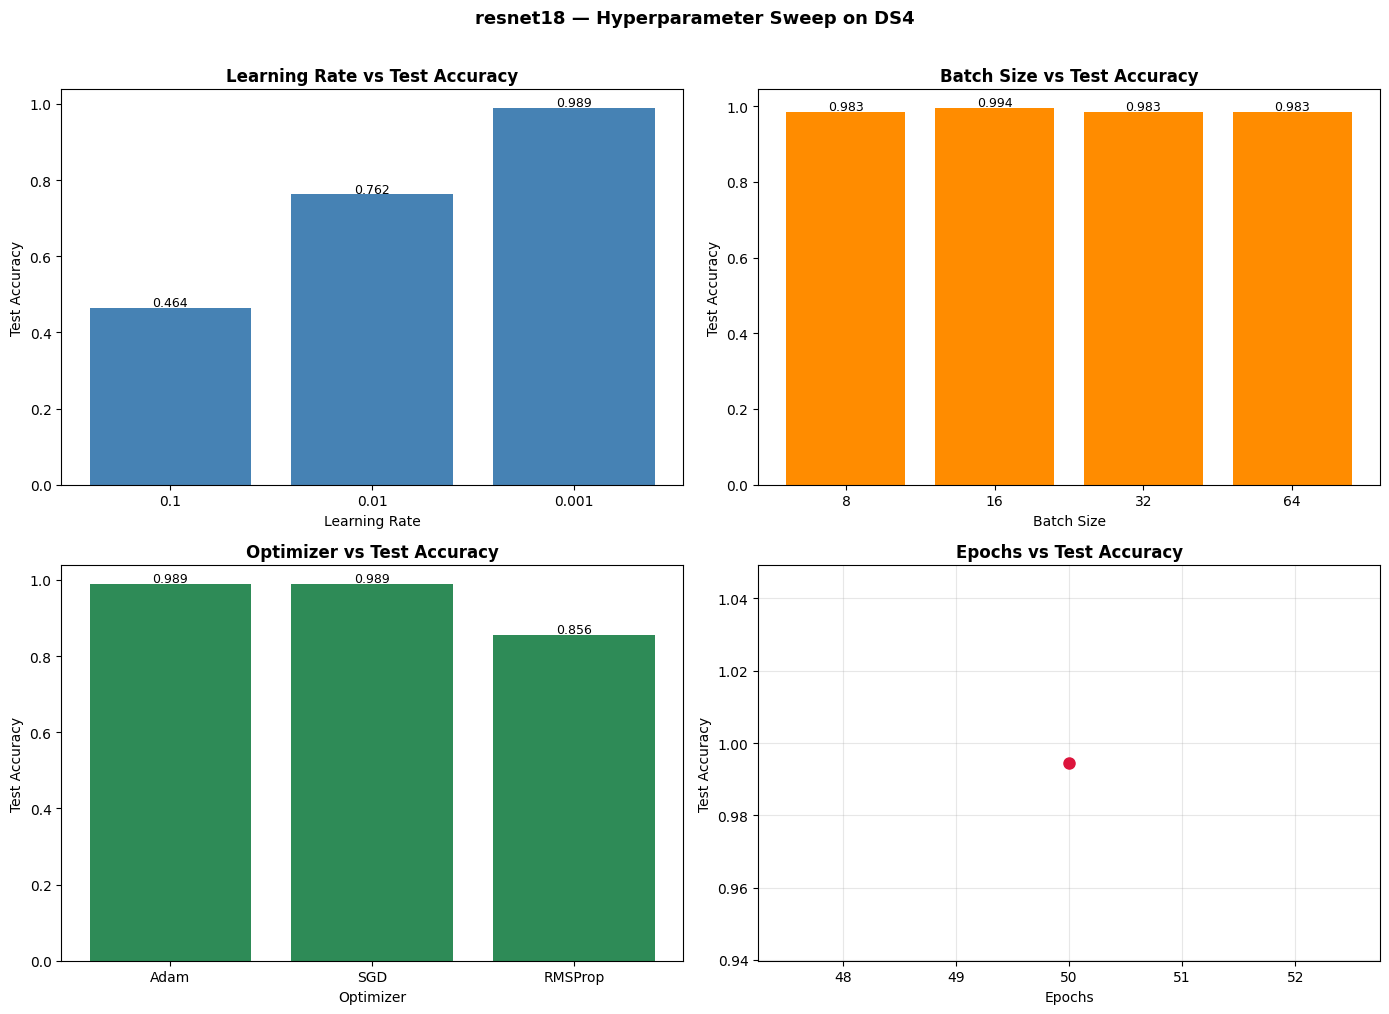

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# LR sweep
ax = axes[0][0]
ax.bar([str(r['lr']) for r in lr_results], [r['test_acc'] for r in lr_results], color='steelblue')
ax.set_title('Learning Rate vs Test Accuracy', fontweight='bold')
ax.set_xlabel('Learning Rate'); ax.set_ylabel('Test Accuracy')
for i, r in enumerate(lr_results):
    ax.text(i, r['test_acc']+0.005, f"{r['test_acc']:.3f}", ha='center', fontsize=9)

# Batch size sweep
ax = axes[0][1]
ax.bar([str(r['bs']) for r in bs_results], [r['test_acc'] for r in bs_results], color='darkorange')
ax.set_title('Batch Size vs Test Accuracy', fontweight='bold')
ax.set_xlabel('Batch Size'); ax.set_ylabel('Test Accuracy')
for i, r in enumerate(bs_results):
    ax.text(i, r['test_acc']+0.005, f"{r['test_acc']:.3f}", ha='center', fontsize=9)

# Optimizer sweep
ax = axes[1][0]
ax.bar([r['opt'] for r in opt_results], [r['test_acc'] for r in opt_results], color='seagreen')
ax.set_title('Optimizer vs Test Accuracy', fontweight='bold')
ax.set_xlabel('Optimizer'); ax.set_ylabel('Test Accuracy')
for i, r in enumerate(opt_results):
    ax.text(i, r['test_acc']+0.005, f"{r['test_acc']:.3f}", ha='center', fontsize=9)

# Epochs sweep
ax = axes[1][1]
ax.plot([r['epochs'] for r in epoch_results], [r['test_acc'] for r in epoch_results],
        'o-', color='crimson', linewidth=2, markersize=8)
ax.set_title('Epochs vs Test Accuracy', fontweight='bold')
ax.set_xlabel('Epochs'); ax.set_ylabel('Test Accuracy')
ax.grid(alpha=0.3)

plt.suptitle(f'{CFG["model_name"]} — Hyperparameter Sweep on {DATASET_ID}',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'/content/hyperparam_sweep_{CFG["model_name"]}_{DATASET_ID}.png', dpi=150, bbox_inches='tight')
plt.show()

In [47]:
import json

# Build comprehensive results
full_results = {
    'main_run': RESULTS,
    'dataset_params': DATASET_PARAMS,
    'lr_sweep': lr_results if 'lr_results' in dir() else [],
    'bs_sweep': bs_results if 'bs_results' in dir() else [],
    'opt_sweep': opt_results if 'opt_results' in dir() else [],
    'epoch_sweep': epoch_results if 'epoch_results' in dir() else [],
    'history': history,
}

fname = f'/content/results_{CFG["model_name"]}_{DATASET_ID}_{CFG["split"]}.json'
with open(fname, 'w') as f:
    json.dump(full_results, f, indent=2)
print(f'✅ Results saved → {fname}')

# Save model weights
model_path = f'/content/model_{CFG["model_name"]}_{DATASET_ID}.pt'
torch.save(model.state_dict(), model_path)
print(f'✅ Model weights saved → {model_path}')

# Download both to local machine
from google.colab import files
files.download(fname)
# files.download(model_path)  # ← uncomment to download weights too

✅ Results saved → /content/results_resnet18_DS4_70_20_10.json
✅ Model weights saved → /content/model_resnet18_DS4.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [48]:
ALL_MODELS = ['resnet18', 'efficientnet_b0', 'inception_v3']
comparison_results = []

for mn in ALL_MODELS:
    print(f' {'='*60}')
    print(f'  Training: {mn.upper()} on {DATASET_ID}')
    print(f'{'='*60}')
    img_sz = 299 if mn == 'inception_v3' else 224

    # Rebuild loaders with correct image size
    tr_t = transforms.Compose([
        transforms.Resize((img_sz+32, img_sz+32)),
        transforms.RandomCrop(img_sz),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    ])
    vt_t = transforms.Compose([
        transforms.Resize((img_sz, img_sz)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    ])
    fd   = datasets.ImageFolder(IMAGE_ROOT, transform=tr_t)
    n    = len(fd)
    nt, nv, nte = int(0.7*n), int(0.2*n), n-int(0.7*n)-int(0.2*n)
    tr_s, vl_s, te_s = random_split(fd, [nt, nv, nte], generator=torch.Generator().manual_seed(42))
    te_s.dataset = datasets.ImageFolder(IMAGE_ROOT, transform=vt_t)
    tr_l = DataLoader(tr_s, 32, shuffle=True,  num_workers=2, pin_memory=True)
    vl_l = DataLoader(vl_s, 32, shuffle=False, num_workers=2, pin_memory=True)
    te_l = DataLoader(te_s, 32, shuffle=False, num_workers=2, pin_memory=True)

    m_cfg = {**CFG, 'model_name': mn, 'img_size': img_sz, 'num_epochs': 30,
             'early_stopping_patience': 8}
    m = build_model(mn, NUM_CLASSES, CFG['dropout_rate'], True, True)
    hist, t_time, mem = train_model(m, tr_l, vl_l, m_cfg, NUM_CLASSES)

    crit = nn.CrossEntropyLoss()
    t0 = time.time()
    tl, ta, tp, tlb, tpr = evaluate(m, te_l, crit, mn)
    inf_t = time.time() - t0
    f1v   = f1_score(tlb, tp, average='weighted', zero_division=0)
    aucv  = compute_auc(tlb, tpr, NUM_CLASSES)
    prec  = precision_score(tlb, tp, average='weighted', zero_division=0)
    rec   = recall_score(tlb,  tp, average='weighted', zero_division=0)

    comparison_results.append({
        'Model': mn, 'Dataset': DATASET_ID,
        'Accuracy': round(ta,4), 'Precision': round(prec,4),
        'Recall': round(rec,4), 'F1': round(f1v,4), 'AUC': round(aucv,4),
        'Train_Time(min)': round(t_time/60,2),
        'Inf_ms/img': round((inf_t/nte)*1000,2),
        'Peak_Mem_MB': round(mem,1),
    })
    del m; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

df_compare = pd.DataFrame(comparison_results)
print(' ' + '='*80)
print(f'  MODEL COMPARISON — Dataset: {DATASET_ID}')
print('='*80)
print(df_compare.to_string(index=False))
df_compare.to_csv(f'/content/comparison_{DATASET_ID}.csv', index=False)
print(f' ✅ Comparison saved → /content/comparison_{DATASET_ID}.csv')

  Training: RESNET18 on DS4
 🚀 Training resnet18 | LR=0.001 | BS=32 | Epochs=30
   Optimizer: Adam | Dropout: 0.4 | Split: 70_20_10
────────────────────────────────────────────────────────────────────────────────
  Epoch    1/30 | Train Loss: 0.3286 Acc: 0.8915 | Val Loss: 0.6277 Acc: 0.8310 | Time: 6.8s
  Epoch    5/30 | Train Loss: 0.0307 Acc: 0.9897 | Val Loss: 0.0110 Acc: 0.9945 | Time: 7.8s
  Epoch   10/30 | Train Loss: 0.0552 Acc: 0.9857 | Val Loss: 0.0162 Acc: 0.9917 | Time: 7.2s
  Epoch   15/30 | Train Loss: 0.0320 Acc: 0.9881 | Val Loss: 0.0523 Acc: 0.9778 | Time: 6.6s
  ⏹  Early stopping at epoch 19 (patience=8)
  Training: EFFICIENTNET_B0 on DS4
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 119MB/s]


 🚀 Training efficientnet_b0 | LR=0.001 | BS=32 | Epochs=30
   Optimizer: Adam | Dropout: 0.4 | Split: 70_20_10
────────────────────────────────────────────────────────────────────────────────
  Epoch    1/30 | Train Loss: 0.2666 Acc: 0.9145 | Val Loss: 0.0935 Acc: 0.9668 | Time: 8.3s
  Epoch    5/30 | Train Loss: 0.0316 Acc: 0.9945 | Val Loss: 0.0123 Acc: 0.9972 | Time: 9.1s
  Epoch   10/30 | Train Loss: 0.0114 Acc: 0.9976 | Val Loss: 0.0007 Acc: 1.0000 | Time: 8.2s
  Epoch   15/30 | Train Loss: 0.0273 Acc: 0.9921 | Val Loss: 0.0112 Acc: 0.9972 | Time: 9.0s
  ⏹  Early stopping at epoch 18 (patience=8)
  Training: INCEPTION_V3 on DS4
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 173MB/s]


 🚀 Training inception_v3 | LR=0.001 | BS=32 | Epochs=30
   Optimizer: Adam | Dropout: 0.4 | Split: 70_20_10
────────────────────────────────────────────────────────────────────────────────
  Epoch    1/30 | Train Loss: 0.4852 Acc: 0.8670 | Val Loss: 0.2374 Acc: 0.9391 | Time: 24.1s
  Epoch    5/30 | Train Loss: 0.1199 Acc: 0.9739 | Val Loss: 0.1400 Acc: 0.9584 | Time: 24.2s
  Epoch   10/30 | Train Loss: 0.0985 Acc: 0.9794 | Val Loss: 0.0436 Acc: 0.9889 | Time: 24.2s
  Epoch   15/30 | Train Loss: 0.0280 Acc: 0.9937 | Val Loss: 0.0125 Acc: 0.9945 | Time: 23.9s
  Epoch   20/30 | Train Loss: 0.0027 Acc: 1.0000 | Val Loss: 0.0063 Acc: 0.9972 | Time: 23.6s
  Epoch   25/30 | Train Loss: 0.1071 Acc: 0.9755 | Val Loss: 0.2804 Acc: 0.9280 | Time: 23.7s
  ⏹  Early stopping at epoch 27 (patience=8)
  MODEL COMPARISON — Dataset: DS4
          Model Dataset  Accuracy  Precision  Recall    F1    AUC  Train_Time(min)  Inf_ms/img  Peak_Mem_MB
       resnet18     DS4     0.989      0.989   0.989 0.989 0

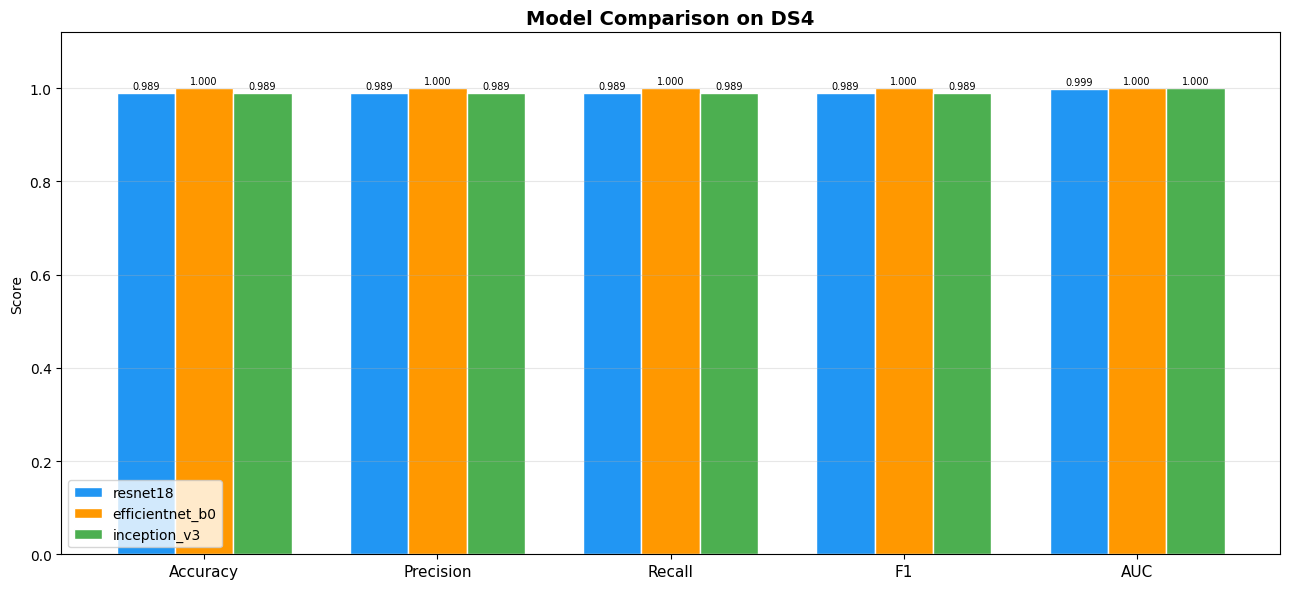

In [49]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
x = np.arange(len(metrics))
width = 0.25
colors = ['#2196F3', '#FF9800', '#4CAF50']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (_, row) in enumerate(df_compare.iterrows()):
    vals = [row[m] for m in metrics]
    bars = ax.bar(x + i*width, vals, width, label=row['Model'], color=colors[i], edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title(f'Model Comparison on {DATASET_ID}', fontsize=14, fontweight='bold')
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'/content/model_comparison_{DATASET_ID}.png', dpi=150, bbox_inches='tight')
plt.show()